<a href="https://colab.research.google.com/github/kananbansal57/task7/blob/main/task7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3

# Connect to or create the database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create the sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sample_data = [
    ('Product A', 10, 5.0),
    ('Product B', 20, 3.0),
    ('Product C', 15, 8.0),
    ('Product A', 5, 5.0),
    ('Product B', 10, 3.0),
    ('Product C', 5, 8.0),
    ('Product D', 7, 6.0)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)

# Commit and close
conn.commit()
conn.close()


Sales Summary:
     product  total_qty  revenue
0  Product A         15     75.0
1  Product B         30     90.0
2  Product C         20    160.0
3  Product D          7     42.0


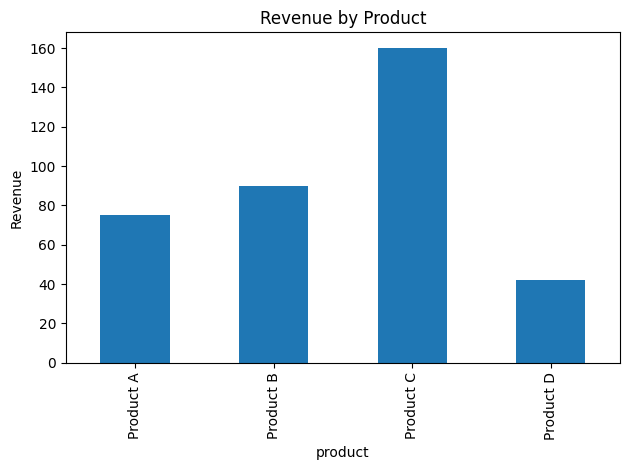

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect("sales_data.db")

# SQL query to get total quantity and revenue per product
query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Run query and load into pandas DataFrame
df = pd.read_sql_query(query, conn)
conn.close()

# Display the DataFrame
print("Sales Summary:")
print(df)

# Plotting the revenue per product
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()
